EDA

In [4]:
import os
import pandas as pd
import matplotlib.pyplot as pyplot
from PIL import Image 
import seaborn as sns

--- ITSD Data Successfully Loaded ---
                     class_name  width  height
0  ALL_MOTOR_VEHICLE_PROHIBITED    218     225
1  ALL_MOTOR_VEHICLE_PROHIBITED    245     238
2  ALL_MOTOR_VEHICLE_PROHIBITED    233     225
3  ALL_MOTOR_VEHICLE_PROHIBITED    146     150
4  ALL_MOTOR_VEHICLE_PROHIBITED    263     265

Total Indian Test Images Found: 1288
Total Unique Indian Classes Found: 85


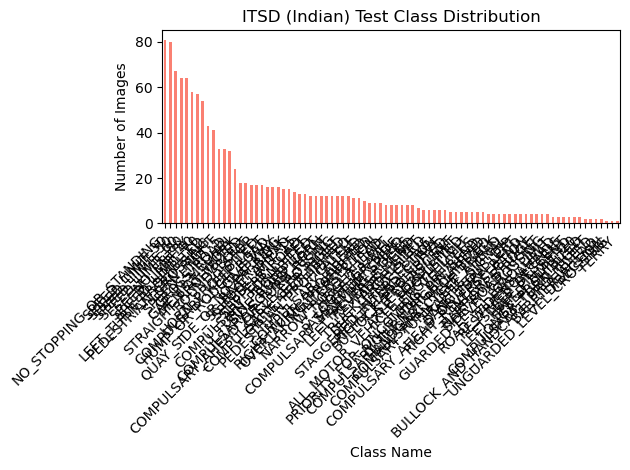

In [5]:
ITSD_TEST_DIR = r"D:\Traffic Sign Classification using CNN\Datasets\ITSD\test"

# 2. Programmatically build a metadata list by scanning folders
data = []

if os.path.exists(ITSD_TEST_DIR):
    for class_name in os.listdir(ITSD_TEST_DIR):
        class_folder = os.path.join(ITSD_TEST_DIR, class_name)
        
        # Ensure we are reading directories, not loose files
        if os.path.isdir(class_folder):
            for img_name in os.listdir(class_folder):
                img_path = os.path.join(class_folder, img_name)
                
                try:
                    with Image.open(img_path) as img:
                        width, height = img.size
                    
                    data.append({
                        "class_name": class_name,
                        "width": width,
                        "height": height
                    })
                except Exception as e:
                    # Skips system files or corrupted images if any exist
                    continue

    # Convert to standard Pandas DataFrame for analysis
    df_itsd = pd.DataFrame(data)
    print("--- ITSD Data Successfully Loaded ---")
    print(df_itsd.head())
    
    # 3. Print Summary Stats
    print(f"\nTotal Indian Test Images Found: {len(df_itsd)}")
    print(f"Total Unique Indian Classes Found: {df_itsd['class_name'].nunique()}")

    # 4. Plot Indian Class Distribution
    df_itsd['class_name'].value_counts().plot(kind='bar', color='salmon')
    pyplot.title("ITSD (Indian) Test Class Distribution")
    pyplot.xlabel("Class Name")
    pyplot.ylabel("Number of Images")
    pyplot.xticks(rotation=45, ha='right')
    pyplot.tight_layout()
    pyplot.show()

else:
    print(f"Error: The path {ITSD_TEST_DIR} does not exist. Double check your folder structure layout!")


In [ ]:

pyplot.figure(figsize=(8, 6))
sns.scatterplot(data=df_itsd, x='width', y='height', alpha=0.6, color='darkcyan')
pyplot.title("ITSD Image Resolution Distribution (Width vs Height)")
pyplot.xlabel("Width (pixels)")
pyplot.ylabel("Height (pixels)")
pyplot.grid(True, linestyle='--', alpha=0.5)
pyplot.show()

# Print out the exact min/max ranges
print(f"Minimum Dimensions: {df_itsd['width'].min()}x{df_itsd['height'].min()}")
print(f"Maximum Dimensions: {df_itsd['width'].max()}x{df_itsd['height'].max()}")

NameError: name 'plt' is not defined